# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Darius Tan Ying Jie



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [55]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# 1. Business Understanding
Goal: Predict HDB resale prices based on property characteristics and location.

# 2. Data Understanding

## 2.1 Load dataset

In [56]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"
df = pd.read_csv(FILE_PATH)
df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,BUKIT MERAH,5 ROOM,87,ZION RD,07 TO 09,117.0,Improved,1974,56 years 05 months,740000.0
1,2018-06,BUKIT MERAH,5 ROOM,87,ZION RD,22 TO 24,114.0,Improved,1974,55 years,820000.0
2,2018-11,BUKIT MERAH,5 ROOM,87,ZION RD,07 TO 09,117.0,Improved,1974,54 years 07 months,735000.0
3,2019-01,BUKIT MERAH,5 ROOM,87,ZION RD,04 TO 06,119.0,Improved,1974,54 years 06 months,750000.0
4,2019-04,BUKIT MERAH,5 ROOM,87,ZION RD,16 TO 18,117.0,Improved,1974,54 years 03 months,825000.0
...,...,...,...,...,...,...,...,...,...,...,...
234063,2026-04,SEMBAWANG,EXECUTIVE,467,ADMIRALTY DR,10 TO 12,137.0,Premium Apartment,2001,74 years 04 months,688888.0
234064,2026-04,SEMBAWANG,EXECUTIVE,467,ADMIRALTY DR,13 TO 15,137.0,Premium Apartment,2001,74 years 03 months,670000.0
234065,2026-04,SEMBAWANG,EXECUTIVE,468A,ADMIRALTY DR,07 TO 09,137.0,Premium Apartment,2001,74 years 01 month,688888.0
234066,2026-05,SEMBAWANG,EXECUTIVE,359A,ADMIRALTY DR,01 TO 03,131.0,Premium Apartment,2001,74 years 05 months,688000.0


## 2.2 Summary Statistics

In [57]:
## Understand the type of variable for each column
df.dtypes

month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64
dtype: object

In [58]:
## Showing the number of rows and columns in the DataFrame stored in df
df.shape

(234068, 11)

In [59]:
## Checking the dataset structure (data types, non-null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234068 entries, 0 to 234067
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                234068 non-null  object 
 1   town                 234068 non-null  object 
 2   flat_type            234068 non-null  object 
 3   block                234068 non-null  object 
 4   street_name          234068 non-null  object 
 5   storey_range         234068 non-null  object 
 6   floor_area_sqm       234068 non-null  float64
 7   flat_model           234068 non-null  object 
 8   lease_commence_date  234068 non-null  int64  
 9   remaining_lease      234068 non-null  object 
 10  resale_price         234068 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.6+ MB


In [60]:
## Describing the data distribution
df.describe(include='all')

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
count,234068,234068,234068,234068,234068,234068,234068.000000,234068,234068.000000,234068,2.340680e+05
unique,114,26,7,2765,578,17,NaN,21,NaN,700,NaN
top,2024-07,SENGKANG,4 ROOM,2,YISHUN RING RD,04 TO 06,NaN,Model A,NaN,94 years 10 months,NaN
freq,3036,18988,99375,706,3312,53671,NaN,84158,NaN,1922,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,96.689712,NaN,1996.552946,NaN,5.314028e+05
std,NaN,NaN,NaN,NaN,NaN,NaN,24.017513,NaN,14.362028,NaN,1.904214e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,NaN,1966.000000,NaN,1.400000e+05
25%,NaN,NaN,NaN,NaN,NaN,NaN,81.000000,NaN,1985.000000,NaN,3.900000e+05
50%,NaN,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,1997.000000,NaN,5.000000e+05
75%,NaN,NaN,NaN,NaN,NaN,NaN,112.000000,NaN,2012.000000,NaN,6.380000e+05


### Checking for any missing/duplicated data

In [61]:
## Check for missing data
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [62]:
## Checking for any duplicated data
df.duplicated().sum()

## While there are some duplicated data (~316). Compared to the sheer number of data in the csv file, there is no need to try to remove these duplicates

np.int64(316)

### Dropping irrelevant colums and making a new column

In [63]:
## Making a new category, called region. This is for one hot endcoding for later. Since trying to one hot endcode towns would result in too much data, we group them into regions
region_dict = {
    "ANG MO KIO":"North-East",
    "BEDOK":"East",
    "BISHAN":"Central",
    "BUKIT BATOK":"West",
    "BUKIT MERAH":"Central",
    "BUKIT PANJANG":"West",
    "BUKIT TIMAH":"Central",
    "CENTRAL AREA":"Central",
    "CHOA CHU KANG":"West",
    "CLEMENTI":"West",
    "GEYLANG":"Central",
    "HOUGANG":"North-East",
    "JURONG EAST":"West",
    "JURONG WEST":"West",
    "KALLANG/WHAMPOA":"Central",
    "MARINE PARADE":"Central",
    "PASIR RIS":"East",
    "PUNGGOL":"North-East",
    "QUEENSTOWN":"Central",
    "SEMBAWANG":"North",
    "SENGKANG":"North-East",
    "SERANGOON":"North-East",
    "TAMPINES":"East",
    "TOA PAYOH":"Central",
    "WOODLANDS":"North",
    "YISHUN":"North"
}
df["region"]=df["town"].map(region_dict)
df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,region
0,2017-01,BUKIT MERAH,5 ROOM,87,ZION RD,07 TO 09,117.0,Improved,1974,56 years 05 months,740000.0,Central
1,2018-06,BUKIT MERAH,5 ROOM,87,ZION RD,22 TO 24,114.0,Improved,1974,55 years,820000.0,Central
2,2018-11,BUKIT MERAH,5 ROOM,87,ZION RD,07 TO 09,117.0,Improved,1974,54 years 07 months,735000.0,Central
3,2019-01,BUKIT MERAH,5 ROOM,87,ZION RD,04 TO 06,119.0,Improved,1974,54 years 06 months,750000.0,Central
4,2019-04,BUKIT MERAH,5 ROOM,87,ZION RD,16 TO 18,117.0,Improved,1974,54 years 03 months,825000.0,Central
...,...,...,...,...,...,...,...,...,...,...,...,...
234063,2026-04,SEMBAWANG,EXECUTIVE,467,ADMIRALTY DR,10 TO 12,137.0,Premium Apartment,2001,74 years 04 months,688888.0,North
234064,2026-04,SEMBAWANG,EXECUTIVE,467,ADMIRALTY DR,13 TO 15,137.0,Premium Apartment,2001,74 years 03 months,670000.0,North
234065,2026-04,SEMBAWANG,EXECUTIVE,468A,ADMIRALTY DR,07 TO 09,137.0,Premium Apartment,2001,74 years 01 month,688888.0,North
234066,2026-05,SEMBAWANG,EXECUTIVE,359A,ADMIRALTY DR,01 TO 03,131.0,Premium Apartment,2001,74 years 05 months,688000.0,North


In [64]:
## Filtering the sample of data taken
## This will reduces dataset size, since it is really big, and narrows the price-trend gap across transaction

## This works as a plain string comparison because 'month' is in a YYYY-MM format, where string order and chronological order match exactly, hence no pd.to_datetime() is used.
df = df[df["month"] >= "2020-01"]
## The reason why the year 2020 was chosen is because Singapore housing market has changed significantly especially since 2020 due to factors such as:
## COVID-19 (around 2020–2022), Rising resale demand, Interest rate changes, Inflation, Government policy adjustments
## All these factors not recorded in the database while not being in there must also be taken in consideration when selecting which part of the data based on date should be chosen
print(df.shape)

(169812, 12)


In [65]:
## Dropping irrelevant columns
col_irrelevant = ["town", "block", "street_name","remaining_lease", "month"] 
## Columns that contain either identifiers (e.g., block, street name) or contain information not useful for training and testing
df = df.drop(col_irrelevant, axis=1)
df

,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,region
7,5 ROOM,10 TO 12,119.0,Improved,1974,820000.0,Central
8,5 ROOM,19 TO 21,119.0,Improved,1974,850000.0,Central
9,5 ROOM,10 TO 12,117.0,Improved,1974,790000.0,Central
10,5 ROOM,22 TO 24,114.0,Improved,1974,850000.0,Central
11,5 ROOM,22 TO 24,114.0,Improved,1974,938000.0,Central
...,...,...,...,...,...,...,...
234063,EXECUTIVE,10 TO 12,137.0,Premium Apartment,2001,688888.0,North
234064,EXECUTIVE,13 TO 15,137.0,Premium Apartment,2001,670000.0,North
234065,EXECUTIVE,07 TO 09,137.0,Premium Apartment,2001,688888.0,North
234066,EXECUTIVE,01 TO 03,131.0,Premium Apartment,2001,688000.0,North


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

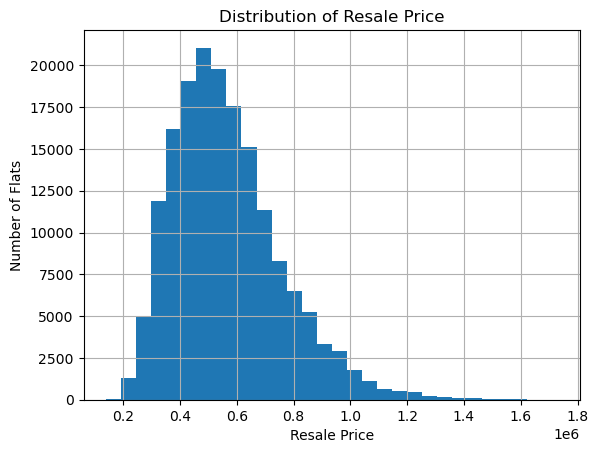

In [66]:
## Understanding distribution of target
## Target variable
col_y = 'resale_price'
 
## Plot distribution of target variable shown as a histogram
df[col_y].hist(bins=30)
plt.title('Distribution of Resale Price')
plt.xlabel('Resale Price')
plt.ylabel('Number of Flats')
plt.show()

## Interpretation:
## The resale price distribution is right-skewed, with most resale prices concentrated between approximately SGD 400,000 and SGD 700,000.
## There are fewer expensive flats above SGD 1 million, creating a long right tail in the distribution.

## Modelling implication:
## The dataset contains high-value properties that may be harder to predict, but the distribution is still suitable for regression modelling.

### 2.3.1.2 Understanding distribution of features

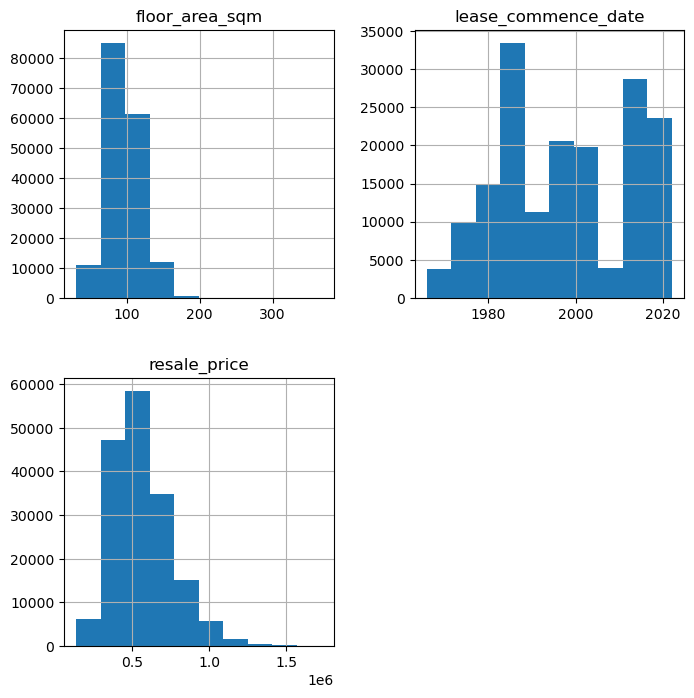

In [67]:
## Understanding distribution of features
## Plot distributions of all numeric features
df.hist(figsize=(8,8))
plt.show()

## Interpretation:
## Most HDB flats have a floor area between roughly 70 and 120 square metres. Lease commencement dates are spread across different construction periods, with more flats built after the mid-1980s.

## Modelling implication:
## Both floor area and lease commencement date contain sufficient variation and are likely to provide useful information for predicting resale prices.

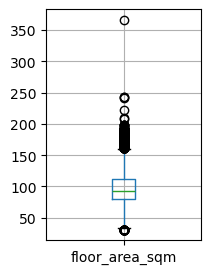

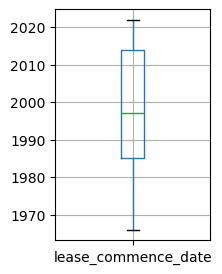

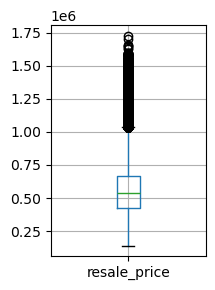

In [68]:
## Boxplot to detect outliers features only (different scale from price)
df[['floor_area_sqm']].boxplot(figsize=(2,3))
plt.show()

## Interpretation:
## Several large floor area values appear as outliers. These likely represent executive flats or jumbo flats.

## Modelling implication:
## The outliers were retained because they are genuine HDB property records rather than data entry errors. Tree-based models such as Random Forest are generally robust to outliers.

df[['lease_commence_date']].boxplot(figsize=(2,3))
plt.show()

## Interpretation:
## Lease commencement dates are fairly well distributed with no significant abnormal outliers.

## Modelling implication:
## The feature was retained because newer flats generally command higher resale prices due to longer remaining leases.

df[['resale_price']].boxplot(figsize=(2,3))
plt.show()

## Interpretation:
## The resale price contains several high-value outliers above SGD 1 million. These correspond to premium HDB flats in desirable locations.

## Modelling implication:
## The outliers were retained because they represent valid market transactions and improve the model's ability to predict expensive properties.

### 2.3.2 Understanding relationship between variables

                     floor_area_sqm  lease_commence_date  resale_price
floor_area_sqm             1.000000             0.061925      0.595320
lease_commence_date        0.061925             1.000000      0.363123
resale_price               0.595320             0.363123      1.000000


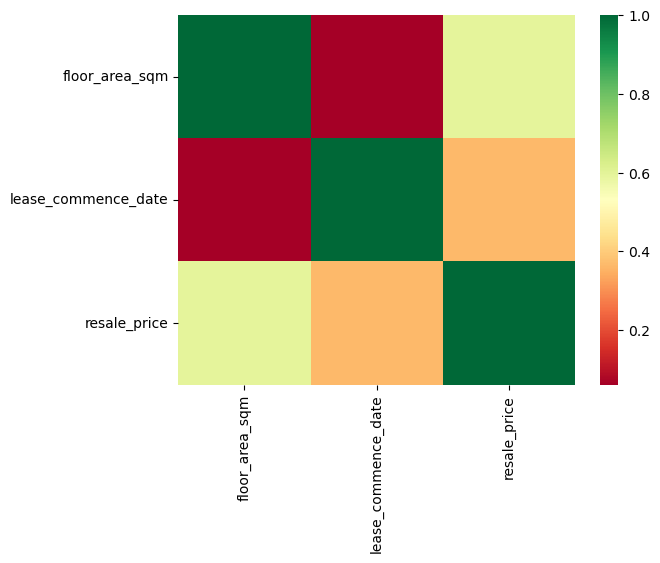

In [69]:
## Understanding relationship between variables
## Select numeric columns (hint: float/int types)
col_numeric = df.select_dtypes(include=['float64', 'int64']).columns
 
## Compute correlation matrix (relationship between numeric variables)
df_corr = df[col_numeric].corr()
print(df_corr)

## Visualization of correlation matrix using heatmap
sns.heatmap(df_corr, cmap='RdYlGn')
plt.show()

## Interpretation:
## Floor area has the strongest positive correlation with resale price (approximately 0.60), indicating that larger flats generally sell for higher prices.
## Lease commencement date also has a positive relationship with resale price (approximately 0.36), suggesting newer flats tend to have higher resale values.

## Modelling implication:
## Both features were retained as important predictors for the regression model.

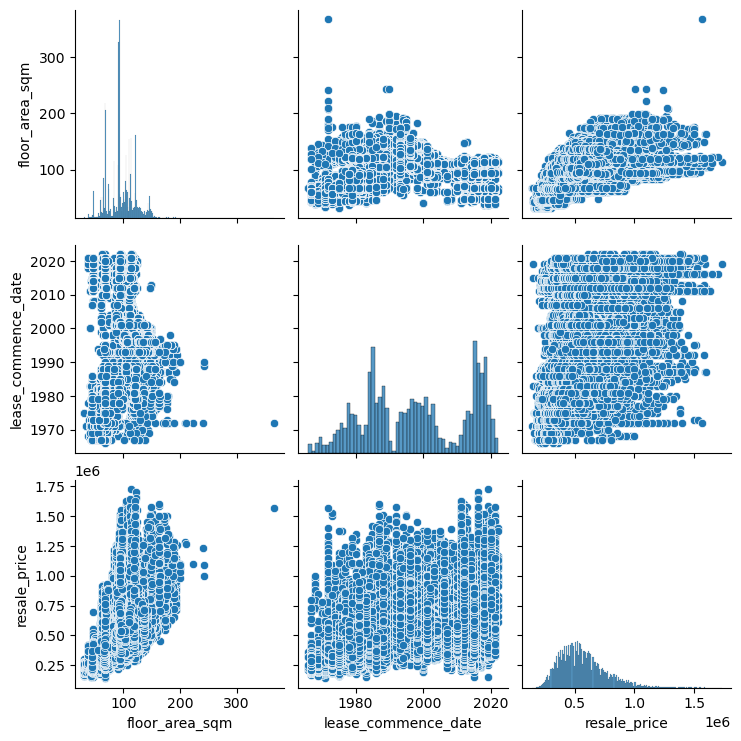

In [77]:
## Pairwise relationships between variables
sns.pairplot(df)
plt.show()

## floor_area_sqm (distribution)
## Interpretation:
## floor_area_sqm is right-skewed with a few large outliers (>300 sqm).
## Modelling implication:
## Consider capping outliers or log-transforming floor_area_sqm.

## lease_commence_date (distribution)
## Interpretation:
## lease_commence_date is multi-modal, with construction peaks in the late 1980s and mid-2010s.
## Modelling implication:
## Treat as categorical/era-based, or derive flat_age instead.

## resale_price (distribution)
## Interpretation:
## resale_price is right-skewed, with a long tail above 1.5M.
## Modelling implication:
## Log-transforming resale_price may improve model performance.

## floor_area_sqm vs resale_price
## Interpretation:
## floor_area_sqm has a clear positive relationship with resale_price.
## Modelling implication:
## Supports including floor_area_sqm as a strong predictor.

## lease_commence_date vs resale_price
## Interpretation:
## Newer leases (post-2010) show a higher price ceiling than older ones.
## Modelling implication:
## Supports including a lease/flat-age feature.

# 3. Data Preparation

## 3.1 Data Cleaning

In [84]:
## Separate features (X) and target (y)

X = df.drop(col_y, axis=1) 
y = df[col_y] 

In [85]:
## Convert categorical variables into numerical format (one-hot encoding)
## This one-hot encoding does not use drop_first so all categories are retained.
## This prevents feature mismatches when predicting on new/unseen data.
X = pd.get_dummies(
    X,
    columns=[
        "region",
        "flat_type",
        "flat_model",
        "storey_range"
    ]
)
X

,floor_area_sqm,lease_commence_date,region_Central,region_East,region_North,region_North-East,region_West,flat_type_1 ROOM,flat_type_2 ROOM,flat_type_3 ROOM,...,storey_range_22 TO 24,storey_range_25 TO 27,storey_range_28 TO 30,storey_range_31 TO 33,storey_range_34 TO 36,storey_range_37 TO 39,storey_range_40 TO 42,storey_range_43 TO 45,storey_range_46 TO 48,storey_range_49 TO 51
7,119.0,1974,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,119.0,1974,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,117.0,1974,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
10,114.0,1974,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
11,114.0,1974,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234063,137.0,2001,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
234064,137.0,2001,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
234065,137.0,2001,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
234066,131.0,2001,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 3.2 Train-Test Split

In [86]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split
 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=2026
)
 
print(X_train.shape)
print(X_test.shape)


(118868, 52)
(50944, 52)


# 4. Modelling

### 4.2 Train Model

In [87]:
## Initialise and train model


# 5. Model Evaluation

In [88]:
## Evaluate model


In [89]:
## New data

## Predict


## Iterative model development


In [90]:
## Further feature engineering / feature selection